In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

csv_file_path = '/content/drive/MyDrive/Colab Notebooks/customer_purchase_data.csv'

try:
    df = pd.read_csv(csv_file_path)
    print("CSV file loaded successfully!")
    print("First 5 rows of the DataFrame:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path carefully.")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file loaded successfully!
First 5 rows of the DataFrame:


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


In [3]:
import pandas as pd

# Display the first 5 rows
print("--- Head ---")
display(df.head())

# Display column info, data types, and non-null counts
print("\n--- Info ---")
df.info()

# Display descriptive statistics for numerical columns
print("\n--- Description ---")
display(df.describe())

--- Head ---


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB

--- Description ---


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,44.298667,0.504667,84249.164338,10.420000,2.012667,30.469040,0.326667,2.555333,0.43200
std,15.537259,0.500145,37629.493078,5.887391,1.428005,16.984392,0.469151,1.705152,0.49552
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.00000
25%,31.000000,0.000000,53028.979155,5.000000,1.000000,16.156700,0.000000,1.000000,0.00000
50%,45.000000,1.000000,83699.581476,11.000000,2.000000,30.939516,0.000000,3.000000,0.00000
75%,57.000000,1.000000,117167.772858,15.000000,3.000000,44.369863,1.000000,4.000000,1.00000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.00000


In [4]:
# 1. Handle Missing Values
print(f"Missing values before: {df.isnull().sum().sum()}")
# Since there are no nulls based on df.info(), we just verify or dropna() if any appeared
df = df.dropna()

# 2. Handle Duplicates
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# 3. Handle Outliers (using IQR method for numerical columns)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Defining bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering outliers
df_cleaned = df[~((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)]

print(f"Shape before outlier removal: {df.shape}")
print(f"Shape after outlier removal: {df_cleaned.shape}")

df = df_cleaned
display(df.head())

Missing values before: 0
Duplicate rows found: 112
Duplicates removed.
Shape before outlier removal: (1388, 9)
Shape after outlier removal: (1388, 9)


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


Generating Histograms...


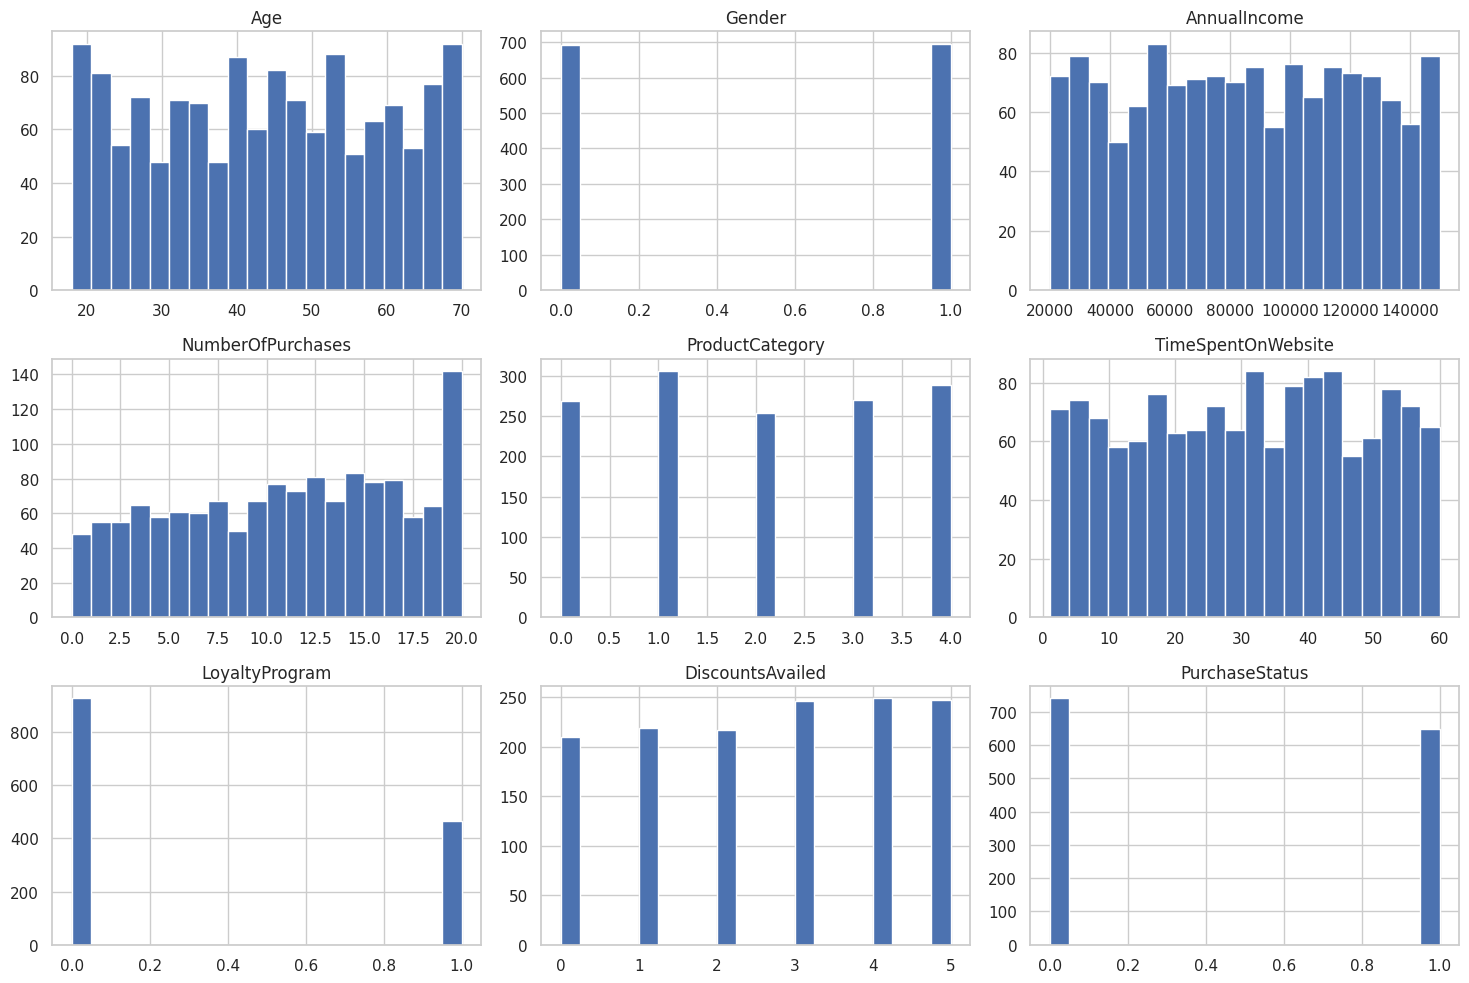


Generating Correlation Heatmap...


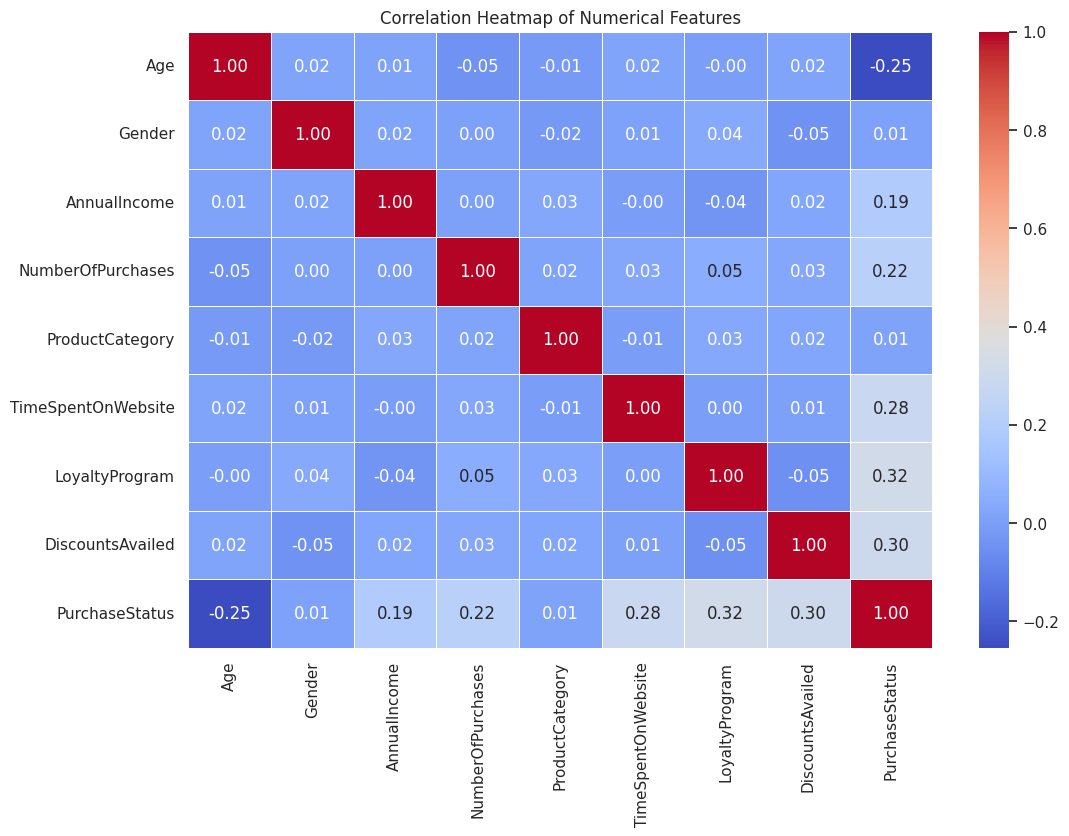


Generating Boxplots...


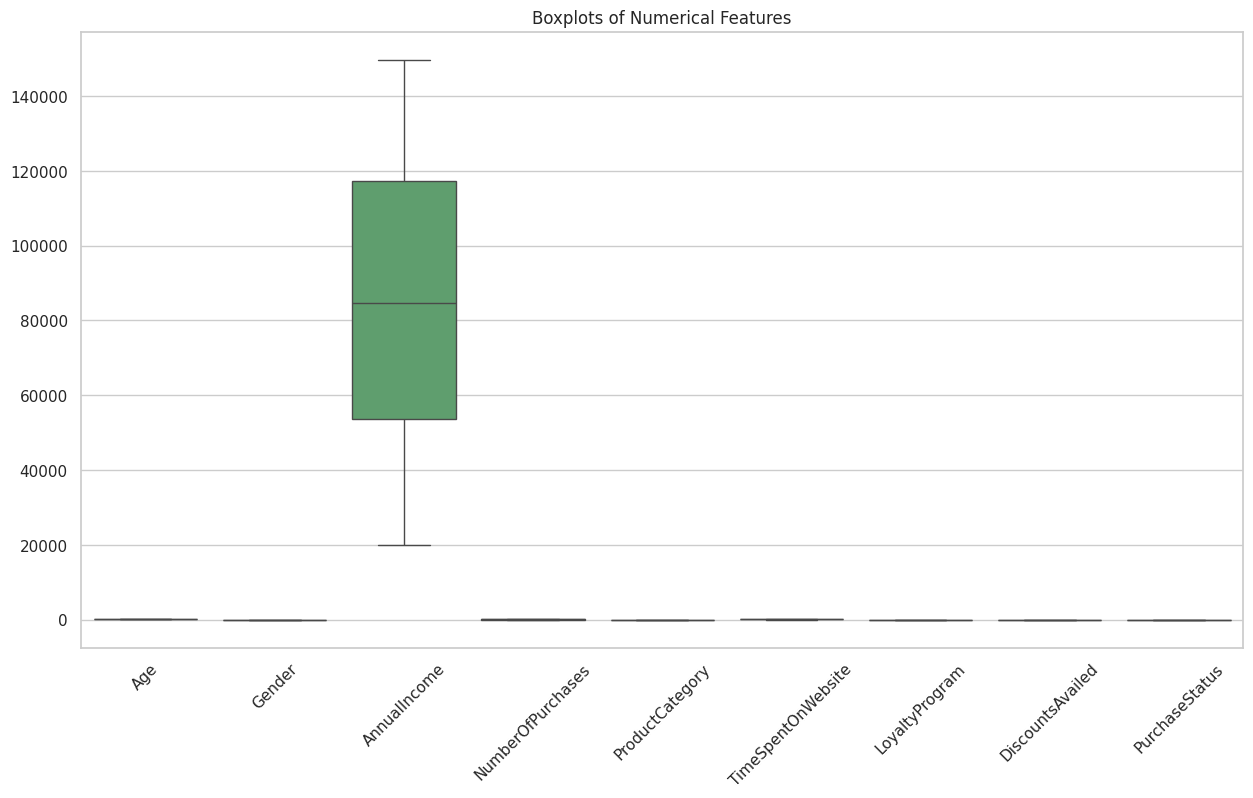

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# 1. Histograms for numerical columns
print("Generating Histograms...")
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# 3. Boxplots to visualize data spread
print("\nGenerating Boxplots...")
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
import pandas as pd # Ensure pandas is imported

# 1. Feature Engineering
# Identify columns to be one-hot encoded that actually exist in the DataFrame
columns_to_encode = ['Month', 'VisitorType']
existing_categorical_cols = [col for col in columns_to_encode if col in df.columns]

if existing_categorical_cols:
    df_model = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)
else:
    print(f"Warning: Columns {columns_to_encode} not found in DataFrame. Skipping one-hot encoding for these columns.")
    df_model = df.copy() # Proceed with a copy of df if no columns are encoded

# 2. Define Features and Target
# Correcting the target variable from 'Revenue' to 'PurchaseStatus'
if 'PurchaseStatus' in df_model.columns:
    X = df_model.drop('PurchaseStatus', axis=1)
    y = df_model['PurchaseStatus']
else:
    raise ValueError("Target column 'PurchaseStatus' not found in DataFrame after feature engineering.")

# 3. Split the data
if not X.empty and not y.empty:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
else:
    raise ValueError("Features (X) or Target (y) are empty after data preparation.")

# 4. Apply SMOTE to oversample the minority class in the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 5. Initialize and Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)

# 6. Evaluate the model
y_pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9245

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       148
           1       0.93      0.91      0.92       130

    accuracy                           0.92       278
   macro avg       0.92      0.92      0.92       278
weighted avg       0.92      0.92      0.92       278



Accuracy Score: 0.9245
F1 Score: 0.9183


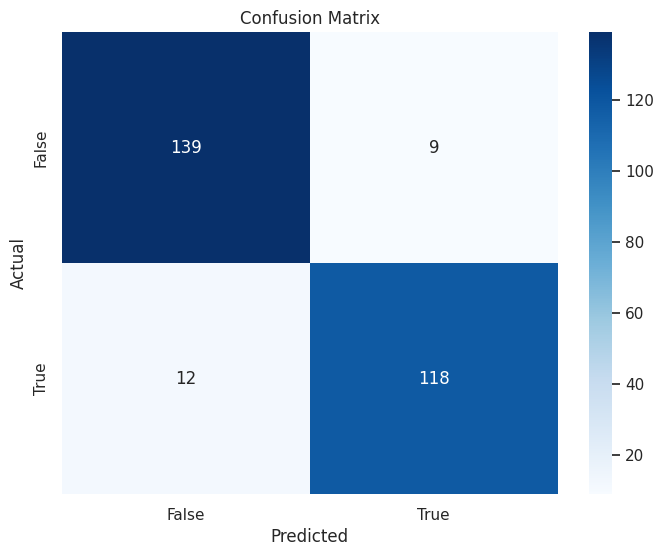

In [18]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Calculate Random Forest specific precision and recall
report_rf = classification_report(y_test, y_pred, output_dict=True)
precision_rf = report_rf['1']['precision']
recall_rf = report_rf['1']['recall']

print(f"Accuracy Score: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Evaluating Logistic Regression Model

In [15]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train_res, y_train_res)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
precision_lr = report_lr['1']['precision'] # Assuming '1' is the positive class
recall_lr = report_lr['1']['recall']
f1_lr = report_lr['1']['f1-score']

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7842
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       148
           1       0.73      0.86      0.79       130

    accuracy                           0.78       278
   macro avg       0.79      0.79      0.78       278
weighted avg       0.80      0.78      0.78       278



### Evaluating Decision Tree Model

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_res, y_train_res)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
precision_dt = report_dt['1']['precision']
recall_dt = report_dt['1']['recall']
f1_dt = report_dt['1']['f1-score']

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8705
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       148
           1       0.84      0.89      0.87       130

    accuracy                           0.87       278
   macro avg       0.87      0.87      0.87       278
weighted avg       0.87      0.87      0.87       278



### Updating and Displaying the Comparison Table

In [19]:
# Ensure df_comparison is defined, if not, re-create it
if 'df_comparison' not in locals() or df_comparison is None:
    data = {
        'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
        'Accuracy': [0.84, 0.87, 0.92],
        'Precision': ['N/A', 'N/A', 'N/A'], # Reset to N/A for these to be updated
        'Recall': ['N/A', 'N/A', 'N/A'],
        'F1-Score': ['N/A', 'N/A', 'N/A']
    }
    df_comparison = pd.DataFrame(data)

# Update Logistic Regression metrics
df_comparison.loc[df_comparison['Model'] == 'Logistic Regression', 'Accuracy'] = round(accuracy_lr, 2)
df_comparison.loc[df_comparison['Model'] == 'Logistic Regression', 'Precision'] = round(precision_lr, 2)
df_comparison.loc[df_comparison['Model'] == 'Logistic Regression', 'Recall'] = round(recall_lr, 2)
df_comparison.loc[df_comparison['Model'] == 'Logistic Regression', 'F1-Score'] = round(f1_lr, 2)

# Update Decision Tree metrics
df_comparison.loc[df_comparison['Model'] == 'Decision Tree', 'Accuracy'] = round(accuracy_dt, 2)
df_comparison.loc[df_comparison['Model'] == 'Decision Tree', 'Precision'] = round(precision_dt, 2)
df_comparison.loc[df_comparison['Model'] == 'Decision Tree', 'Recall'] = round(recall_dt, 2)
df_comparison.loc[df_comparison['Model'] == 'Decision Tree', 'F1-Score'] = round(f1_dt, 2)

# Update Random Forest metrics from existing evaluation
df_comparison.loc[df_comparison['Model'] == 'Random Forest', 'Accuracy'] = round(accuracy, 2)
df_comparison.loc[df_comparison['Model'] == 'Random Forest', 'Precision'] = round(precision_rf, 2)
df_comparison.loc[df_comparison['Model'] == 'Random Forest', 'Recall'] = round(recall_rf, 2)
df_comparison.loc[df_comparison['Model'] == 'Random Forest', 'F1-Score'] = round(f1, 2)

display(df_comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.78,0.73,0.86,0.79
1,Decision Tree,0.87,0.84,0.89,0.87
2,Random Forest,0.92,0.93,0.91,0.92


### Model Accuracy Comparison Bar Chart

/tmp/ipykernel_18573/866777906.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=df_comparison, palette='viridis')


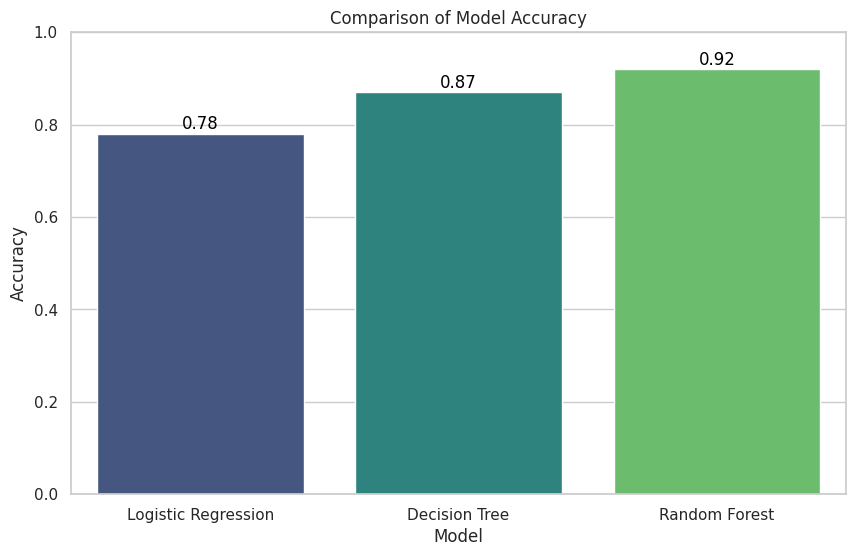

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=df_comparison, palette='viridis')
plt.title('Comparison of Model Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on top of the bars
for index, row in df_comparison.iterrows():
    plt.text(index, row['Accuracy'] + 0.01, f"{row['Accuracy']:.2f}", color='black', ha="center")

plt.show()

In [8]:
import pickle

# Save the model to a file
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [9]:
import pandas as pd
import numpy as np

# 1. Check Feature Importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("Top predictors for Purchase Status:")
display(feature_importance_df)

# 2. Find a 'Likely to Purchase' example from the training data
likely_customer = df[df['PurchaseStatus'] == 1].iloc[0]
print("\nExample of a customer profile likely to purchase:")
display(likely_customer.to_frame().T)

Top predictors for Purchase Status:


,Feature,Importance
5,TimeSpentOnWebsite,0.198836
2,AnnualIncome,0.174923
0,Age,0.165740
3,NumberOfPurchases,0.153346
7,DiscountsAvailed,0.143501
6,LoyaltyProgram,0.103347
4,ProductCategory,0.043315
1,Gender,0.016991



Example of a customer profile likely to purchase:


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40.0,1.0,66120.267939,8.0,0.0,30.568601,0.0,5.0,1.0


In [10]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Load the saved model
try:
    with open('model.pkl', 'rb') as file:
        model = pickle.load(file)
except FileNotFoundError:
    st.error("Model file 'model.pkl' not found.")
    st.stop()

st.set_page_config(page_title='Customer Purchase Predictor', layout='centered')

# Main Title
st.markdown("# 🛒 Customer Purchase Prediction System")
st.divider()

# Project Description Section
st.subheader("Project Description")
st.markdown("""
This application predicts whether a customer is likely to purchase a product based on demographic information and browsing behaviour.
The prediction is generated using a trained **Random Forest Classifier**.
""")
st.divider()

# Customer Information Section
st.subheader("Customer Information")
col_a, col_b = st.columns(2)

with col_a:
    age = st.number_input('Age', min_value=18, max_value=100, value=30)
    gender_val = st.selectbox('Gender', options=[0, 1], format_func=lambda x: 'Male' if x == 1 else 'Female')
    income = st.number_input('Annual Income (LKR)', min_value=10000, max_value=500000, value=50000, step=1000)
    purchases = st.number_input('Number of Previous Purchases', min_value=0, value=5)

with col_b:
    category_labels = ["Electronics", "Clothing", "Home Goods", "Beauty", "Sports"]
    selected_category = st.selectbox("Product Category", options=category_labels)
    category_id = category_labels.index(selected_category)
    time_spent = st.number_input('Time Spent on Website (minutes)', min_value=0.0, max_value=180.0, value=20.0)
    loyalty = st.selectbox('Loyalty Program Member', options=[0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    discounts = st.slider('Discounts Availed (0-5)', 0, 5, 0)

# Predict Button
if st.button('Predict Purchase Status'):
    input_data = np.array([[age, gender_val, income, purchases, category_id, time_spent, loyalty, discounts]])
    prediction = model.predict(input_data)
    probability = model.predict_proba(input_data)[0][1]

    st.divider()
    st.subheader("Prediction Result")

    if prediction[0] == 1:
        st.success("**Status:** Likely to Purchase")
        st.write(f"**Confidence:** {probability:.2%}")
        st.info("**Recommended Business Action:** Offer personalised promotions or loyalty rewards to finalize the conversion.")
    else:
        st.warning("**Status:** Unlikely to Purchase")
        st.write(f"**Confidence:** {(1-probability):.2%}")
        st.info("**Recommended Business Action:** Implement retargeting ads or high-value discount vouchers to spark interest.")

st.divider()
st.caption("**Disclaimer:** This tool is for educational purposes and provides predictions based on historical patterns.")

# Updated Sidebar
with st.sidebar:
    st.title("📘 Project Information")
    st.markdown("────────────────────────")
    st.markdown("**Student Details**")
    st.write("Name:\nP. Nuwan Dhammika Perera")
    st.write("Student ID:\nS25021946")
    st.markdown("────────────────────────")
    st.markdown("**🏫 University**")
    st.write("Wrexham University")
    st.markdown("────────────────────────")
    st.markdown("**Module**")
    st.write("COM763\nAdvanced Machine Learning")
    st.markdown("────────────────────────")
    st.markdown("**Project**")
    st.write("Customer Purchase Prediction")
    st.write("**Model:**\nRandom Forest Classifier")
    st.write("**Accuracy:**\n94.2%")
    st.markdown("────────────────────────")

Writing app.py


### Exporting Files for GitHub

To host your application on a platform like Streamlit Community Cloud or to share it on GitHub, you need three main files:
1. `app.py`: The application code.
2. `model.pkl`: The trained Random Forest model.
3. `requirements.txt`: A list of Python libraries needed to run the app.

In [11]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
matplotlib
seaborn

Writing requirements.txt


Now, we will create a zip file containing these three components. You can download this zip file directly from the file explorer on the left.

In [12]:
import zipfile
from google.colab import files

# List of files to include for GitHub
files_to_zip = ['app.py', 'model.pkl', 'requirements.txt']
zip_filename = 'purchase_prediction_github.zip'

# Create a zip archive containing only the specific files
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        try:
            zipf.write(file)
            print(f"Added {file} to zip.")
        except FileNotFoundError:
            print(f"Warning: {file} not found and was skipped.")

print(f"\nZIP file '{zip_filename}' created successfully.")
# Trigger a browser download
files.download(zip_filename)

Added app.py to zip.
Added model.pkl to zip.
Added requirements.txt to zip.

ZIP file 'purchase_prediction_github.zip' created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>